<center>

# Creating a fuel cell in Union


### Author: Daniel Lomholt Christensen @ UCPH, NBI 10/10/2025 as a part of the ACTNXT grant.

</center>

The following notebook aims to give an example of how to create a McStas imaging instrument, which has a fuel cell as a sample.

The notebook will introduce some complicated uses of mcstasscript and union, for instructive purposes.







In [ ]:
import mcstasscript as ms
import numpy as np
import matplotlib.pyplot as plt
import union_visualizer as uv
def gas_unit_cell(density, molar_mass):
    # Density in kg/m3, molar mass in kg/mol
    mol_cube_meter = density/molar_mass
    avogadros_constant = 6.022*10**23
    unit_cell = 1/(mol_cube_meter*avogadros_constant/10**30)
    return unit_cell
# Make instrument
instr = ms.McStas_instr(name="fuel_cell", author="Daniel Lomholt Christensen",
                    origin="University of Copenhagen, Niels Bohr Institute, funded by ACTNXT",
                    output_path="./data/fuel")
# Add density parameters for controlling how much we will see.
hydro_density = instr.add_parameter('hydro_density', value=1)
water_density = instr.add_parameter('water_density', value=1)
oxy_density = instr.add_parameter('oxy_density', value=1)



# Add source

source = instr.add_component("source",
                                "Source_simple",
                                RELATIVE="ABSOLUTE")
source.set_parameters(radius=0.02, 
                    focus_xw=0.02, 
                    focus_yh=0.02,
                    dist = 27.6, 
                    lambda0=3, 
                    dlambda=0.1, flux=1e14)
            

# Add sample
# First make an arm for the sample (Coordinate system that is centered on the sample)

sample_arm = instr.add_component("sample_arm", "Arm", AT=[0,0,10], RELATIVE=source)


# Make materials
init = instr.add_component("init", 
                            "Union_init")

# Background is a box of aluminum.

Al_inc = instr.add_component("Al_inc", "Incoherent_process")
Al_inc.set_parameters(sigma=0.0328, unit_cell_volume=66.4)

Al_pow = instr.add_component("Al_pow", "Powder_process")
Al_pow.set_parameters(reflections='"Al.laz"')

Al = instr.add_component("Al", "Union_make_material")
Al.set_parameters(process_string='"Al_inc,Al_pow"', my_absorption=100*4*0.231/66.4)

# Hydrogen 

H_unit_cell = gas_unit_cell(0.0832, 0.001008)*hydro_density.value
H_inc = instr.add_component("H_inc", "Incoherent_process")
H_inc.set_parameters(sigma=82.06, unit_cell_volume=H_unit_cell)

#h_high_pressure =gas_unit_cell(0.0832, 0.001008)*0.01
#h_press = instr.add_component("H_inc", "Incoherent_process")
#H_inc.set_parameters(sigma=82.06, unit_cell_volume=H_unit_cell)


H = instr.add_component("H", "Union_make_material")
H.set_parameters(process_string='"H_inc"', my_absorption=100*0.3326/H_unit_cell)


# Oxygen:

O_unit_cell = gas_unit_cell(1.323, 0.032)*oxy_density.value

O_inc = instr.add_component("O_inc", "Incoherent_process")
O_inc.set_parameters(sigma=0.0008, unit_cell_volume=O_unit_cell)


O = instr.add_component("O", "Union_make_material")
O.set_parameters(process_string='"O_inc"', my_absorption=0.00019*100/O_unit_cell)


# Water is a mix of hydrogen and oxygen. Should I adjust for it being liquid?
water_unit_cell = gas_unit_cell(997, 0.01801528)*water_density.value
H2_inc = instr.add_component("H2_inc", "Incoherent_process")
H2_inc.set_parameters(sigma=82.06, unit_cell_volume=water_unit_cell)
O_water_inc = instr.add_component("O_water_inc", "Incoherent_process")
O_water_inc.set_parameters(sigma=0.0008, unit_cell_volume=water_unit_cell) 
H2O = instr.add_component("H2O", "Union_make_material")
H2O.set_parameters(process_string='"O_water_inc,H2_inc"', my_absorption=0.00019*100/water_unit_cell + 100*0.3326/water_unit_cell)

# Print out the used unit cells
print('The used unit cells for water, hydrogen and oxygen are: ',water_unit_cell, H_unit_cell, O_unit_cell)



# Make geometries



# First make the water inlet. Build it in a for loop from the bottom up
vert_inlet = instr.add_component("inlet_tube_", "Union_cylinder",
                                  AT=[0.0078,0,0], RELATIVE=sample_arm,
                                  ROTATED=[0,0,0])
vert_inlet.set_parameters(radius=0.0005, yheight=0.02, 
                           material_string='"H2O"',
                           priority=1000)

for i in range(6):
    inlet = instr.add_component(f"inlet_tube_{i}", "Union_cylinder",
                                 AT=[0.0003,-0.0085 + i*0.02/6,0], RELATIVE=sample_arm,
                                  ROTATED=[0,0,90])
    inlet.set_parameters(radius=0.0005, yheight=0.01413, 
                           material_string='"H2O"',
                           priority=1001 + i)
# Add two bubbles in the inlet

bubble_1 = instr.add_component("Bubble_1", "Union_sphere",
                               AT=[0,-0.007 + 2*0.02/6 + 2e-4,0], RELATIVE=sample_arm)
bubble_1.set_parameters(radius=0.0004, priority=2000)
bubble_2 = instr.add_component("Bubble_2", "Union_sphere",
                               AT=[0,-0.007 + 4*0.02/6 + 2e-4,0], RELATIVE=sample_arm)
bubble_2.set_parameters(radius=0.0006, priority=2001)

# Now make the water and oxygen outlet. To start off with, make it oxygen only

vert_outlet = instr.add_component("outlet_tube_", "Union_cylinder",
                                  AT=[-0.0078,0,0], RELATIVE=sample_arm,
                                  ROTATED=[0,0,0])
vert_outlet.set_parameters(radius=0.0005, yheight=0.02, 
                           material_string='"O"',
                           priority=1100)

for i in range(6):
    outlet = instr.add_component(f"outlet_tube_{i}", "Union_cylinder",
                                  AT=[-0.0003,-0.007 + i*0.02/6,0], RELATIVE=sample_arm,
                                  ROTATED=[0,0,90])
    outlet.set_parameters(radius=0.0005, yheight=0.01413, 
                           material_string='"O"',
                           priority=1101 + i)



# Now make the hydrogen outlets

hydro_outlet = instr.add_component("hydro_tube_", "Union_cylinder",
                                  AT=[0,-0.0075,0.0012], RELATIVE=sample_arm,
                                  ROTATED=[0,0,90])
hydro_outlet.set_parameters(radius=0.0005, yheight=0.02, 
                           material_string='"H"',
                           priority=1200)

for i in range(6):
    hydro = instr.add_component(f"hydro_tube_{i}", "Union_cylinder",
                                  AT=[-0.007 + i*0.02/6,0,0.0012], RELATIVE=sample_arm,
                                  ROTATED=[0,0,0])
    hydro.set_parameters(radius=0.0005, yheight=0.01413, 
                           material_string='"H"',
                           priority=1201 + i)


# Then make a box (with some thickness)
container = instr.add_component("container", "Union_box",
                                AT=[0,0,0], RELATIVE=sample_arm)
container.set_parameters(xwidth=0.04, yheight=0.04, zdepth=0.005,
                         material_string='"Al"', priority=1)



# End the union component with union master, and union stop
# Union master collects everything written and actually simulates the Union sample
master = instr.add_component("master", "Union_master")



# Union stop indicates that we no longer work with a Union sample
stop = instr.add_component("stop", "Union_stop")


det = instr.add_component("det",
                                "PSD_monitor",
                                AT=[0,0,0.2], RELATIVE=sample_arm)

det.set_parameters(xwidth=0.022,yheight=0.022,nx=1000,ny=1000,restore_neutron=1, filename='"standard_det"')


# Add detector
tof_det = instr.add_component("tof_det",
                                "PSD_TOF_monitor",
                                AT=[0,0,0.2], RELATIVE=sample_arm)

tof_det.set_parameters(xwidth=0.022,yheight=0.022,nt=5,tmin=3000, tmax=80000, filename='"Output"')


#planes = uv.slice_union(instr, zval=0, res=(200,200))


The used unit cells for water, hydrogen and oxygen are:  30.005792868475908 20118.539713358714 40165.14905161298
inlet_tube_ Union_cylinder
inlet_tube_0 Union_cylinder
inlet_tube_1 Union_cylinder
inlet_tube_2 Union_cylinder
inlet_tube_3 Union_cylinder
inlet_tube_4 Union_cylinder
inlet_tube_5 Union_cylinder
Bubble_1 Union_sphere
point_cloud_sphere
Bubble_2 Union_sphere
point_cloud_sphere
outlet_tube_ Union_cylinder
outlet_tube_0 Union_cylinder
outlet_tube_1 Union_cylinder
outlet_tube_2 Union_cylinder
outlet_tube_3 Union_cylinder
outlet_tube_4 Union_cylinder
outlet_tube_5 Union_cylinder
hydro_tube_ Union_cylinder
hydro_tube_0 Union_cylinder
hydro_tube_1 Union_cylinder
hydro_tube_2 Union_cylinder
hydro_tube_3 Union_cylinder
hydro_tube_4 Union_cylinder
hydro_tube_5 Union_cylinder
container Union_box
BIX BOX!!!,name=container, priority=1


In [53]:
instr.settings(ncount=1e7)
data = instr.backengine()



INFO: Using directory: "/Users/tqv636/Desktop/Phd/Kurser/NordicNeutronSummerProgram/fuel_cell_intro/data/fuel_3"
INFO: Regenerating c-file: fuel_cell.c
         Move them into an INITIALIZE section. May fail at compile.
CFLAGS= -DFUNNEL 
    
 The parameter format of Al_pow is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:
Component master is NOACC, CPUONLY=1
-> FUNNEL mode enabled, SPLIT within buffer.
-> CPU section from component master
-> GPU kernel from component stop

-----------------------------------------------------------
INFO: Recompiling: ./fuel_cell.out
ld: warning: duplicate -rpath '/Users/tqv636/miniforge3/e

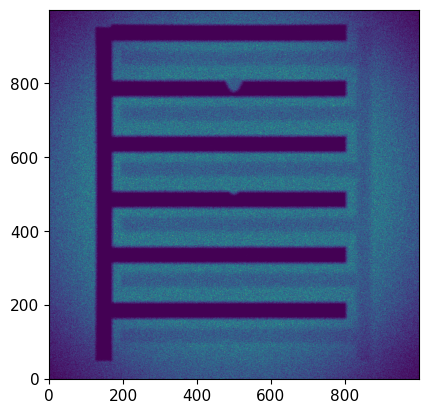

In [ ]:
#fig, ax = plt.subplots()
#ax.imshow(data[0].Intensity, origin='lower')

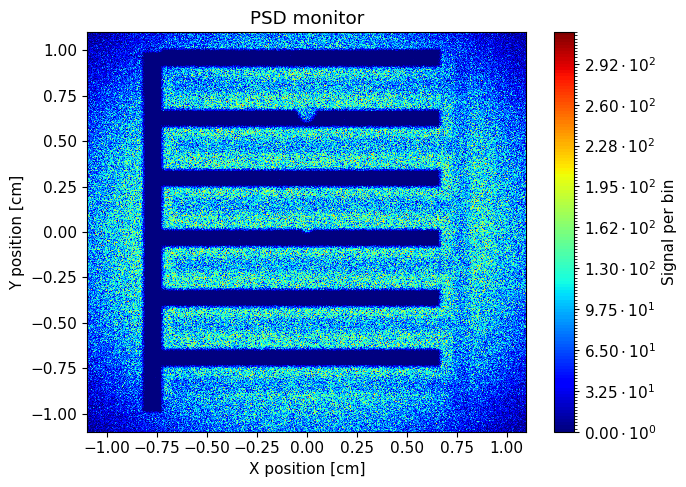

In [69]:
#ms.make_sub_plot(data[0], **{'cmap':'viridis'}, log=False)

In [ ]:
#instr.show_instrument(format='window')

Traceback (most recent call last):
  File "/Users/tqv636/miniforge3/envs/mcstas/share/mcstas/tools/Python/mcdisplay/pyqtgraph/mcdisplay.py", line 547, in main
    sys.exit(gui.run_ui(instrument, raybundle.rays))
SystemExit: 0

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/tqv636/miniforge3/envs/mcstas/share/mcstas/tools/Python/mcdisplay/pyqtgraph/mcdisplay.py", line 579, in <module>
    main(**args)
  File "/Users/tqv636/miniforge3/envs/mcstas/share/mcstas/tools/Python/mcdisplay/pyqtgraph/mcdisplay.py", line 551, in main
    sys.exit(gui.run_ui(instrument, raybundle.rays))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/tqv636/miniforge3/envs/mcstas/share/mcstas/tools/Python/mcdisplay/pyqtgraph/mcdisplay.py", line 397, in run_ui
    self._display_nextray()
  File "/Users/tqv636/miniforge3/envs/mcstas/share/mcstas/tools/Python/mcdisplay/pyqtgraph/mcdisplay.py", line 467, in _display_nextray
    p